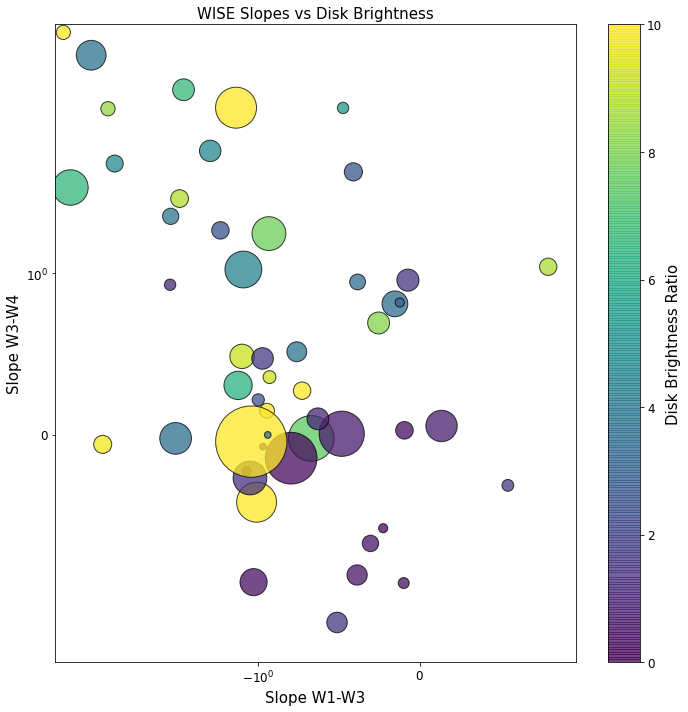

In [2]:
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
# Open the data file and read in all the lines
#filename1 = 'list2.txt'
#with open(filename1) as data:
 #   lines1 = data.read().splitlines()
    
# Open the data file and read in all the lines
filename = 'slopes2.txt'
with open(filename) as data:
    lines = data.read().splitlines()
    
# Define a list to hold the scaled relative disk brightness
scaled_brightness = []
for line in lines:
    Columns = line.split(' ')
    scaled_brightness.append(Columns[4])
    
filename = 'slopes new.txt'
with open(filename) as slopes:
    line = slopes.read().splitlines()

# Define a list to hold the W3-W4 slopes
slope_W3W4 = []
# Append the list with the data from the correct column
for row in line:
    Columns = row.split(' ')
    slope_W3W4.append(Columns[1])
    
slope_W1W3 = []
for row in line:
    Columns = row.split(' ')
    slope_W1W3.append(Columns[0])
    
# Open the data file and read in all the lines
file = 'dust mass.txt'
with open(file) as values:
    read = values.read().splitlines()
    
# Define a list to hold the dust mass values
dust_mass = []
for line in read:
    Columns = line.split(' ')
    dust_mass.append(Columns[1])

# Convert to floats
#slope_W1W2 = [float(a) for a in slope_W1W2]
slope_W3W4 = [float(b) for b in slope_W3W4]
#slope_W2W3 = [float(d) for d in slope_W2W3]
slope_W1W3 = [float(f) for f in slope_W1W3]
#disk_brightness = [float(c) for c in brightness_values]
scaled_brightness = [float(e) for e in scaled_brightness]
dust_mass = [float(c) for c in dust_mass]

size = [500*n for n in scaled_brightness]
s = [500*n for n in dust_mass]

# Plot
plt.figure(figsize=(10, 10))
plt.scatter(slope_W1W3, slope_W3W4, c=scaled_brightness, cmap='viridis', s=s, edgecolors='k', alpha=0.75)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=12)
cbar.set_label(label='Disk Brightness Ratio', fontsize=15)
plt.xlabel('Slope W1-W3', fontsize=15)
plt.ylabel('Slope W3-W4', fontsize=15)
plt.title('WISE Slopes vs Disk Brightness', fontsize=15)
plt.xticks(ticks=slope_W1W3, labels=slope_W1W3, fontsize=12)
plt.yticks(ticks=slope_W3W4, labels=slope_W3W4, fontsize=12)
plt.xscale('symlog')
plt.yscale('symlog')
plt.clim(0, 10)
plt.minorticks_on()
plt.tight_layout()
plt.savefig('plot.jpg')
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy
from astroquery.vizier import Vizier
import astropy.units as u
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
from astropy.coordinates import Angle
from astropy.table import Table

In [4]:
# Query Gaia catalog
gaia_result = Vizier(catalog='I/345/gaia2', columns=['*', '_RAJ2000', '_DEJ2000'], row_limit=1000000, timeout=120).query_constraints(DE_ICRS='<30', Gmag='<13.5', Plx='2.0..5.0')[0]
print(gaia_result)

     _RAJ2000          _DEJ2000         RA_ICRS     ...  Rad      Lum   
       deg               deg              deg       ... solRad   solLum 
----------------- ----------------- --------------- ... ------ ---------
109.2856766302970 -37.0974567411585 109.28559761664 ...     --        --
296.5649245528980  10.6132550297278 296.56498394402 ...     --        --
261.3249434998111 -55.5298997966559 261.32488980467 ...     --        --
 83.1825520373913 -17.8222697558083  83.18258425115 ...     --        --
 93.7193553605536  22.5067873271708  93.71907791954 ...     --        --
  3.3089235146215  15.1835384975820   3.30896790080 ...     --        --
154.2707162917272 -61.3323087239936 154.27050158993 ...     --        --
116.3137295098023 -37.9685827152569 116.31367603504 ... 111.02  4669.431
117.3235564367008 -24.8597857051839 117.32353930286 ... 119.21  6150.412
252.9675653854427 -38.0473987266926 252.96756079205 ...     --        --
              ...               ...             ...

In [5]:
# Query WISE catalog using Gaia coordinates
wise_result = Vizier(catalog='II/311/wise', row_limit=200000, timeout=120).query_region(gaia_result, radius="2s")[0]

In [6]:
print(wise_result)

  _q           WISE         RAJ2000    DEJ2000   eeMaj  ...  ex var   d2M   _2M
                              deg        deg     arcsec ...          arcsec    
------ ------------------- ---------- ---------- ------ ... --- ---- ------ ---
     1 J071708.43-370551.3 109.285158 -37.097589  0.050 ...   1 nnnn  1.314  2M
     2 J194615.52+103648.5 296.564673  10.613490  0.073 ...   1 nnnn  1.282  2M
     4 J053243.84-174919.0  83.182688 -17.821952  0.028 ...   1 nn95  0.887  2M
     6 J001314.07+151101.1   3.308625  15.183665  0.108 ...   1 2091  1.167  2M
     9 J074917.68-245134.4 117.323687 -24.859568  0.044 ...   1 nn99  0.602  2M
    10 J165152.19-380250.6 252.967488 -38.047410  0.040 ...   1 4099  0.485  2M
    11 J053212.78+183540.1  83.053273  18.594495  0.046 ...   1 nnnn  0.813  2M
    13 J172523.64-562239.9 261.348526 -56.377756  0.077 ...   0 0000  0.554  2M
    15 J100720.02+164545.6 151.833453  16.762694  0.062 ...   1 1n20  1.163  2M
    17 J095651.72-543404.2 149.215538 -5

In [7]:
data = wise_result.to_pandas()
#print(df)

In [8]:
# Extract star names and magnitudes from pandas dataframe
#for i in range(len(data)):
 #   magnitudes = data[['WISE', 'W1mag', 'W2mag', 'W3mag', 'W4mag']]
#print(magnitudes)

In [9]:
# Convert columns to arrays
stars = data['WISE'].to_numpy()
RA_DEC = data[['RAJ2000', 'DEJ2000']].to_numpy()
W1mag = data['W1mag'].to_numpy()
W2mag = data['W2mag'].to_numpy()
W3mag = data['W3mag'].to_numpy()
W4mag = data['W4mag'].to_numpy()

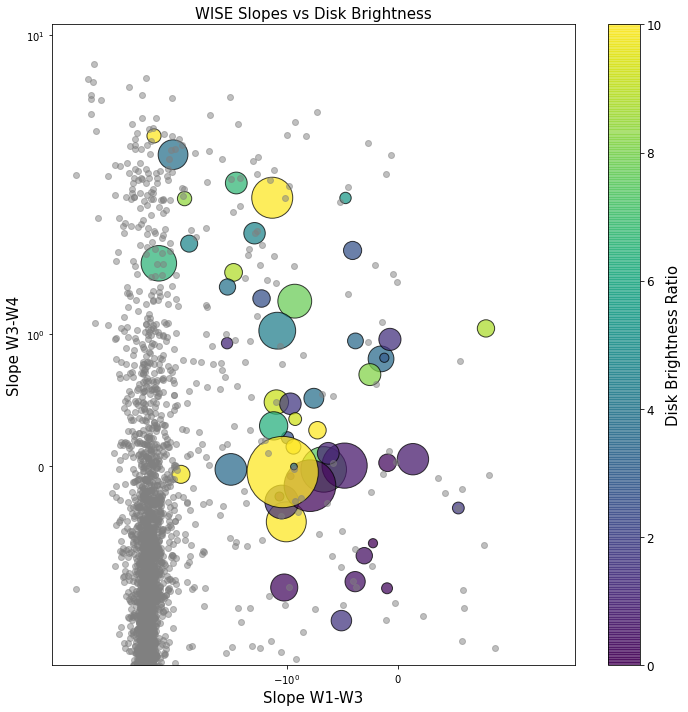

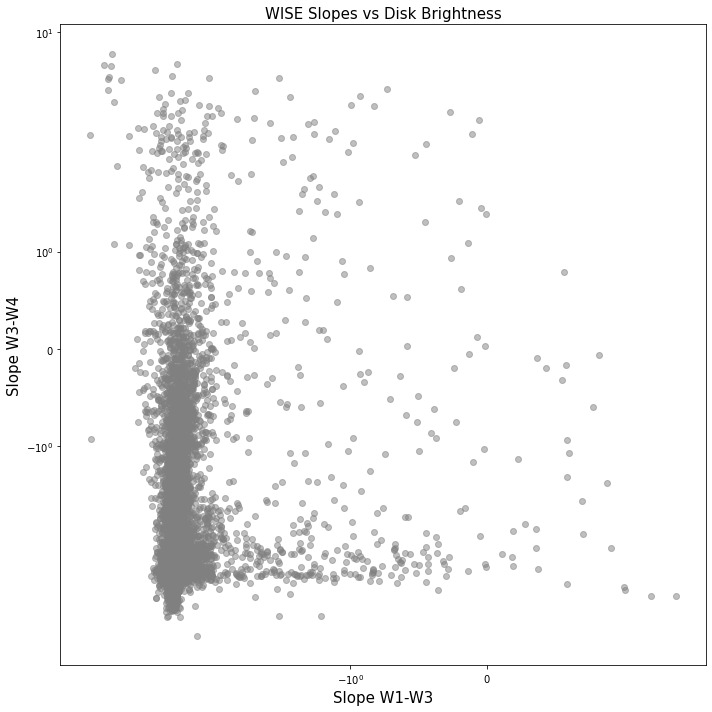

In [21]:
# Convert the magnitudes to flux density
W1_flux_d = (309.540 * 10**(-W1mag/2.5))
W2_flux_d = (171.787 * 10**(-W2mag/2.5))
W3_flux_d = (31.676 * 10**(-W3mag/2.5))
W4_flux_d = (8.363 * 10**(-W4mag/2.5))

# Frequency of each of the WISE bands
W1_freq = 8.95e-13
W2_freq = 6.52e-13
W3_freq = 2.59e-13
W4_freq = 1.36e-13

#Convert flux density to flux
W1_flux = np.log10(W1_freq * W1_flux_d)
W2_flux = np.log10(W2_freq * W2_flux_d)
W3_flux = np.log10(W3_freq * W3_flux_d)
W4_flux = np.log10(W4_freq * W4_flux_d)

# wavelength values for each WISE band
W1_wavelength = np.log10(3.35)
W2_wavelength = np.log10(4.6)
W3_wavelength = np.log10(11.6)
W4_wavelength = np.log10(22.1)

# Calculate the slopes
slope1 = (W3_flux - W1_flux) / (W3_wavelength - W1_wavelength)
slope2 = (W4_flux - W3_flux) / (W4_wavelength - W3_wavelength)

# Plot
plt.figure(figsize=(10, 10))
plt.scatter(slope_W1W3, slope_W3W4, c=scaled_brightness, cmap='viridis', s=s, edgecolors='k', alpha=0.75)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=12)
cbar.set_label(label='Disk Brightness Ratio', fontsize=15)
plt.clim(0, 10)
plt.scatter(slope1, slope2, c='gray', alpha=0.5)
plt.xlabel('Slope W1-W3', fontsize=15)
plt.ylabel('Slope W3-W4', fontsize=15)
plt.title('WISE Slopes vs Disk Brightness', fontsize=15)
#plt.xticks(ticks=slope_W1W3, labels=slope_W1W3, fontsize=12)
#plt.yticks(ticks=slope_W3W4, labels=slope_W3W4, fontsize=12)
plt.xscale('symlog')
plt.yscale('symlog')
plt.ylim(-1.5)
plt.minorticks_on()
plt.tight_layout()
plt.savefig('new_sample.jpg')
plt.show()

plt.figure(figsize=(10, 10))
plt.scatter(slope1, slope2, c='gray', alpha=0.5)
plt.xlabel('Slope W1-W3', fontsize=15)
plt.ylabel('Slope W3-W4', fontsize=15)
plt.title('WISE Slopes vs Disk Brightness', fontsize=15)
#plt.xticks(ticks=slope_W1W3, labels=slope_W1W3, fontsize=12)
#plt.yticks(ticks=slope_W3W4, labels=slope_W3W4, fontsize=12)
plt.xscale('symlog')
plt.yscale('symlog')
#plt.ylim(-1)
plt.minorticks_on()
plt.tight_layout()
plt.savefig('sample.jpg')
plt.show()

In [17]:
sample_stars_coords = []
for i in range(len(RA_DEC)):
    if slope1[i] < 0 and slope2[i] > 0:
        sample_stars_coords.append(RA_DEC[i])

# Print the selected stars
print(len(sample_stars_coords))
print("Stars with negative ratio between Wise 1 and 3 and positive ratio between 3 and 4:")
print(sample_stars_coords)

540
Stars with negative ratio between Wise 1 and 3 and positive ratio between 3 and 4:
[array([102.240602, -15.144689]), array([83.381034, -1.156051]), array([84.363968, -5.938367]), array([83.058939, 17.058107]), array([317.198433, -76.212158]), array([122.585699, -49.23737 ]), array([161.934609, -59.875256]), array([84.062628, -5.647905]), array([88.644566, -4.064701]), array([84.696686, -2.594559]), array([267.8023 , -30.55697]), array([84.690098, -2.599677]), array([85.234911, -1.507157]), array([283.636798,  20.615353]), array([239.183357, -53.788943]), array([90.99227 ,  2.864353]), array([135.175262, -38.419476]), array([83.769958, -4.731823]), array([83.888983, -4.837551]), array([127.06561 , -51.770386]), array([265.040535, -39.205004]), array([84.985701, -1.926695]), array([242.411138, -52.115331]), array([85.084142, -2.435578]), array([83.237846, -4.56645 ]), array([85.05642, -1.46252]), array([269.32214 , -38.782693]), array([83.775882, -5.204452]), array([133.010182, -46.2

In [18]:
coords = [102.240602, -15.144689], [83.381034, -1.156051], [84.363968, -5.938367], [83.058939, 17.058107], [317.198433, -76.212158], [122.585699, -49.23737 ], [161.934609, -59.875256], [84.062628, -5.647905], [88.644566, -4.064701], [84.696686, -2.594559], [267.8023 , -30.55697], [84.690098, -2.599677], [85.234911, -1.507157], [283.636798,  20.615353], [239.183357, -53.788943], [90.99227 ,  2.864353], [135.175262, -38.419476], [83.769958, -4.731823], [83.888983, -4.837551], [127.06561 , -51.770386], [265.040535, -39.205004], [84.985701, -1.926695], [242.411138, -52.115331], [85.084142, -2.435578], [83.237846, -4.56645 ], [85.05642, -1.46252], [269.32214 , -38.782693], [83.775882, -5.204452], [133.010182, -46.288827], [268.319817, -27.629006], [84.652283, -2.55352 ], [122.613521, -49.164162], [82.740615,  4.668727], [148.165624, -55.453899], [272.528626, -23.772822], [283.366395,   0.8703  ], [291.521468,   3.519354], [284.041249,   7.935613], [242.650657, -51.968855], [267.051102, -28.762958], [272.269364, -19.875223], [250.349704, -46.385806], [109.272599, -37.113424], [83.609419, -4.371205], [290.837856,  14.713033], [151.8793  , -57.550024], [80.032397, -5.846091], [270.212328, -24.7886  ], [85.752434, -2.312584], [265.009412, -32.160322], [253.973445, -43.070831], [83.054505, -1.60047 ], [164.775486, -61.12778 ], [289.966835,  14.063967], [84.461819, -6.722091], [270.293073, -23.554374], [254.574935, -41.076437], [84.533369, -1.752157], [84.526974, -0.184393], [150.119991, -59.992382], [85.4702  , -2.798545], [251.342367, -44.763949], [166.532167, -61.054433], [141.838331, -53.968846], [281.361409,  -3.231188], [270.908275, -23.138134], [83.80836 , -5.826721], [161.114758, -59.884825], [160.951565, -59.101511], [307.456043,  20.605129], [272.675361, -17.918152], [285.37182 ,   4.257983], [130.721102, -48.128088], [264.972951, -32.375537], [243.375848, -51.617412], [284.781749,   3.427768], [211.804645, -61.423548], [248.529172, -48.079753], [283.636798,  20.615353], [289.679463, -17.008528], [243.943237, -49.253379], [254.406329, -43.057241], [97.901345,  4.933203], [161.465801, -60.192383], [85.588754, -8.133375], [164.268514, -61.18829 ], [156.855143, -59.945398], [159.266562, -58.965945], [133.849965,  19.699867], [156.789665, -57.186091], [83.734296, -4.76596 ], [286.511435,   7.349011], [249.749127, -45.593225], [250.888517, -46.839834], [298.754632,  11.613901], [86.07834 ,  0.144562], [290.713015,  13.37536 ], [290.544285,  14.016115], [80.120565, -5.812167], [245.043597, -51.236984], [291.294547,  17.390448], [254.035707, -42.603359], [245.608276, -49.950315], [82.918667, -1.125881], [83.73039 , -5.506134], [83.80512 , -4.594731], [245.180361, -50.736677], [83.993864, -5.375554], [249.940746, -46.86258 ], [260.807157, -31.490511], [79.922557,  5.645261], [274.057116, -16.801589], [274.334697, -12.232011], [135.106059, -47.256212], [238.966166, -53.356208], [274.928249, -18.162666], [245.027604, -50.830687], [239.579409, -53.000117], [256.944249, -24.773566], [244.784784, -51.094052], [83.87981 , -4.904224], [124.076732, -44.343467], [170.079696, -61.945984], [198.318893, -63.300743], [261.767618, -34.671443], [154.916967, -58.096326], [184.070065, -62.99366 ], [98.334684,  4.64946 ], [169.860127, -60.57744 ], [110.765666, -25.531447], [105.929937, -11.551312], [131.982413, -42.58948 ], [84.113276, -5.408688], [83.781804, -5.868956], [245.527806, -50.473509], [243.701621, -51.808883], [165.033372, -59.978429], [247.096002, -48.320531], [265.847717, -27.261412], [290.800148,  13.338485], [161.105608, -60.212718], [273.60392 , -17.952713], [249.892164, -46.650375], [110.95098 , -44.463154], [274.026168, -17.085449], [274.643734, -13.906078], [247.612445, -48.156532], [127.378404, -38.615514], [213.640529, -61.799012], [264.921842, -32.29941 ], [240.098837, -50.864396], [160.580603, -59.170885], [165.315038, -61.261744], [281.710837,  -2.377114], [297.512938,  25.201705], [242.404728, -52.180347], [250.177902, -47.668905], [83.892814, -5.10592 ], [272.661186, -19.299325], [235.750907, -54.007666], [292.506931,  18.432174], [249.892164, -46.650375], [279.311246,  -6.604953], [164.218777, -61.424348], [ 80.892379, -11.977957], [83.8056 , -4.86249], [270.95784 , -25.079068], [265.008174, -32.34579 ], [157.211821, -56.737531], [267.956118, -35.102168], [92.829734, -5.191166], [200.783221, -64.59539 ], [85.239471, -1.837527], [98.291982,  4.280069], [245.502777, -50.326157], [249.615677, -48.704604], [198.414788, -63.683772], [254.916288, -42.504886], [232.968541, -56.178033], [273.4682 , -17.38928], [232.857608, -55.943498], [82.284977, 11.87023 ], [266.662879, -28.897658], [253.267372, -45.386497], [253.539329, -43.194933], [286.086955,   5.115576], [218.891404, -44.449764], [85.668308, -4.81994 ], [134.99887 , -47.630958], [286.072179,   4.976028], [280.33315 ,  -3.784126], [243.723396, -51.317027], [284.521507,   1.605273], [141.150942, -52.11348 ], [238.61669 , -53.745633], [152.555506, -57.306121], [274.413298,  -9.367807], [216.934385, -65.143429], [271.053276, -24.361911], [290.441244,  14.36391 ], [159.774033, -58.767882], [261.610338, -34.283698], [ 21.311099, -45.941082], [244.451282, -50.968181], [259.030539, -38.855   ], [138.851667, -47.738419], [287.880114,  10.417445], [287.435208,   8.539612], [235.000361, -54.003989], [165.518225, -71.49824 ], [162.728076, -59.85343 ], [283.03881,  -0.96075], [260.028138, -37.257566], [274.38841 , -17.947964], [282.25966 ,  -0.841898], [135.342406, -48.896885], [262.376388, -35.691928], [271.616844, -44.915055], [84.843056,  8.208345], [210.983983, -62.331974], [281.745711,  -3.779966], [150.97411 , -57.776123], [266.463787, -29.512823], [165.453829, -61.774245], [161.124481, -59.538493], [256.292138, -40.702155], [282.189509, -11.705236], [161.446118, -58.679856], [122.369333, -38.858128], [85.192199, -1.926664], [278.793333,  -7.414715], [83.750602, -4.526806], [271.062154, -22.058925], [245.080703, -25.612022], [265.4462  , -32.092878], [97.562356,  4.443479], [259.283717, -34.119517], [83.676166, -5.120723], [251.950595, -46.250148], [255.104311, -40.506926], [262.220322, -34.760368], [263.746386, -33.614889], [279.651067,  -5.950911], [261.973856, -34.961987], [243.926285, -50.084523], [125.332392, -40.622711], [112.383011, -73.37872 ], [216.730338, -60.7648  ], [252.816594, -45.694513], [169.632571, -60.821309], [287.776021,   9.645564], [83.826849, -4.682165], [255.330896, -38.182502], [81.675584, -4.192228], [277.60364,   1.2233 ], [275.149168, -12.847998], [275.096367, -15.940359], [ 80.749081, -68.064176], [83.762497,  9.934659], [83.838731, -5.154608], [166.899502, -60.613351], [274.526658, -13.607335], [288.426062,  10.983181], [256.703557, -41.020617], [247.612506, -48.738774], [96.282952, -4.858308], [313.350408, -71.837144], [266.986095, -29.550063], [254.965816, -25.171914], [81.033518,  2.463053], [265.72581 , -29.978455], [266.798547, -28.712923], [159.321788, -58.709362], [159.145793, -58.837948], [305.298309,  24.553482], [275.265326, -14.161677], [85.236325, -2.149236], [83.210095, -1.600741], [284.947311,   4.112496], [280.563459,  -2.328495], [ 93.017415, -20.910825], [259.945992, -39.294875], [248.890536, -48.933893], [160.663104, -59.471276], [282.153651,  -1.176286], [83.859041, -5.804612], [82.35351 ,  3.725161], [228.448016, -56.428794], [88.427137,  9.362642], [270.381037, -24.136237], [263.545364, -31.716389], [222.32815, -59.4134 ], [265.052602, -32.159182], [210.952237, -61.94458 ], [136.836433, -47.115332], [84.521894, -1.256013], [84.238871, -1.435382], [270.250976, -23.910271], [215.780169, -60.429969], [170.009823, -65.266516], [250.181695, -48.814416], [295.834719,  23.029317], [81.910881, -1.967152], [251.31765, -45.00587], [100.313765,   9.52125 ], [297.606871,  26.454054], [276.758693, -12.838803], [273.140516, -18.48229 ], [64.942445, 19.761079], [273.1193  , -18.647476], [187.958247, -62.234857], [111.860703, -20.132761], [274.114029, -17.573926], [131.975743, -43.567122], [134.392364, -42.732296], [122.935718, -44.085757], [135.537461, -46.931532], [153.690898, -57.875523], [274.642797, -14.223351], [183.648175, -51.552064], [164.240654, -61.110743], [270.19941 , -18.754786], [159.431838, -59.496801], [97.667717,  5.377427], [244.348841, -50.86488 ], [297.977615,  26.486075], [292.392976,  17.996119], [221.50502 , -59.268105], [124.063778, -34.826956], [265.01252 , -32.222062], [171.029073, -61.728698], [241.280294, -53.245375], [216.083018, -62.182756], [108.448974, -46.582953], [265.074107, -32.182835], [98.407347, -4.848807], [166.534822, -58.67076 ], [254.532355, -44.003735], [284.039722,   2.295472], [264.263712, -32.562144], [154.816636, -58.112587], [125.799401, -39.117085], [257.030729, -41.657636], [161.046767, -59.925204], [79.001975, -9.809822], [ 2.82155551e+02, -3.59920000e-02], [235.886323, -54.05573 ], [282.586586,  -1.585737], [82.970439, 11.010609], [153.621552, -57.630914], [197.997418, -63.239956], [284.237894,   4.121678], [225.715863, -61.812336], [250.693956, -46.199136], [279.660295,  -5.83482 ], [245.121698, -50.587911], [274.946883, -11.914667], [168.639666, -60.759147], [259.516897, -38.381135], [84.014916, -4.75198 ], [260.360423, -38.717273], [274.736288, -11.283359], [267.156504, -29.474457], [113.899365,   0.237566], [247.629747, -47.173422], [272.432322, -19.314459], [260.307778, -37.315767], [283.521842,   1.20191 ], [252.627914, -46.167564], [245.959394, -49.398368], [286.81816,   7.08138], [279.374201,  -6.176179], [260.111679, -33.085753], [258.898338, -41.351619], [253.48297 , -45.277477], [258.389327, -39.010311], [67.026976, 19.601879], [149.869453, -56.937809], [281.711184,  -2.485401], [253.751199, -39.701046], [123.522944, -41.667915], [68.267593, 29.363883], [286.102478,   5.721208], [246.621773, -48.820865], [264.510923, -31.84735 ], [267.085251, -31.387161], [260.198089, -33.70502 ], [279.452084,  -8.741836], [121.119975, -48.263242], [220.175823, -60.819612], [259.346857, -38.857036], [83.717706, -5.552339], [254.419877, -40.529618], [188.167866, -62.720748], [272.385737, -19.054294], [255.126368, -40.304596], [287.817096, -20.805327], [215.640442, -61.149049], [264.278186, -31.976511], [270.874552, -24.018905], [ 2.83615374e+02, -9.36400000e-02], [139.800718, -52.020272], [133.577477,  19.907965], [159.831872, -58.266754], [245.507309, -48.684786], [209.223196, -61.60683 ], [282.420552,  -0.831689], [235.386322, -53.963287], [83.480305, -5.647366], [287.366507,  -0.829191], [266.975727, -28.626719], [292.277809,  16.770295], [249.184192, -48.074363], [142.90326 , -52.487712], [145.329319, -54.243223], [243.64588 , -49.803879], [191.977306, -63.451567], [290.080221,  -8.06167 ], [272.300107, -20.252813], [246.900575, -49.821747], [182.743814, -62.657148], [298.222784, -16.998953], [251.256725, -45.244097], [260.780995, -35.979743], [76.712795, -3.333214], [311.007725,  19.212911], [285.450478,   4.218047], [97.980039,  4.2409  ], [ 2.243353, -0.256417], [273.470301, -17.911145], [286.732197,   5.242675], [273.655047, -17.907405], [261.476287, -40.244787], [161.782096, -60.158405], [83.558996, -5.615044], [201.121505, -30.433766], [81.178342,  1.73008 ], [93.08005,  4.52684], [292.79323 ,  18.527454], [280.954856,  -1.854835], [239.893607, -53.725776], [125.921569, -42.831924], [285.202843,   3.962574], [211.041036, -60.373605], [157.945851, -58.062433], [260.481702, -38.274619], [271.759445, -25.616009], [132.697468, -43.038553], [249.704757, -47.669967], [153.149564, -57.596725], [283.884846,   0.80804 ], [80.720574,  0.932746], [256.032163, -38.261125], [253.806231, -43.116864], [274.402396, -16.732629], [165.61315 , -60.751771], [133.269896, -42.575403], [244.603189, -51.652357], [261.124428, -36.747758], [238.449729, -53.374288], [197.36545 , -62.218331], [263.184672, -32.965073], [229.721373, -56.73348 ], [97.900368,  4.795985], [295.924688,  23.269623], [182.726361, -62.956081], [274.368361, -12.534645], [278.722148,  -8.632173], [239.168266, -54.364753], [177.452821,   1.57724 ], [296.835993,  24.619735], [292.965198,  18.645667], [214.138426, -61.645552], [283.732366,   1.253898], [133.076828, -42.19785 ], [148.709498, -60.598533], [235.587284, -54.344962], [202.659695, -62.998722], [83.767924, -5.136874], [264.368308, -31.82721 ], [240.367153, -52.399428], [292.684447,  29.467871], [254.343023, -49.810248], [301.852977,  27.551159], [92.146244, 20.441416], [231.246104, -56.346033], [131.835684, -42.724372], [324.794547, -46.097638], [251.945235, -45.14563 ], [83.40925 , -1.590801], [83.546412, -5.38181 ], [262.112214, -35.116819], [278.25391 ,  -5.271217], [241.844871, -51.395564], [152.878392, -58.963512], [277.018874, -13.736163], [152.089865, -57.351586], [261.742241, -30.106011], [86.68631 ,  0.089713], [228.922927, -58.128944], [264.926776, -32.099153], [98.286443,  4.763059], [129.584104,  28.63973 ], [213.941738, -60.061687], [8.6680764e+01, 7.6695000e-02], [98.529073,  4.79057 ], [81.944748, 17.735422], [275.178914, -13.561511], [210.113931, -62.777773], [265.660764,  -6.451243], [190.544363, -43.944317], [280.00394 ,  -4.840674], [ 1.01585127e+02, -5.69360000e-02], [138.835036, -52.756053], [234.330522, -56.793569], [282.08449 ,  19.109072], [281.103041,  -4.316759], [84.157559, -6.425099], [ 93.133694, -27.186346], [217.71228 , -62.160232], [98.138357,  4.748085], [273.242481,  27.467038], [273.906537, -17.09795 ], [184.517609, -62.409435], [260.17946, -33.14448], [160.290098, -59.396224], [99.815817,  8.766798], [239.503371, -53.625894], [265.028518, -32.230686], [259.027056, -21.032886], [215.691798, -61.041872], [97.909636,  4.341094], [250.689402, -46.578179], [250.288113, -46.08043 ], [254.20147 , -40.818535], [155.655331, -57.453707], [132.139122, -43.504843], [244.92485 , -50.175511], [263.64236 , -32.602493], [82.248774,  3.363527]

In [19]:
from astroquery.simbad import Simbad

# Initialize Vizier
simbad VizIdentifier", "RAJ2000", "DEJ2000"], timeout=200000)


# Loop through each coordinate and query Vizier
for i, (ra, dec) in enumerate(coords):
    c = coord.SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
    result = simbad_region(c, radius=2*u.arcsec)
    
    # Print result
    #print(f"Coordinate {i+1} (RA: {ra}, Dec: {dec}):")
    #if result:
     #   print(result[0])
    #else:
     #   print("No match found")
    #print()
    
    for row in result[0]:
            print(f"{row['Identifier']},{row['RAJ2000']},{row['DEJ2000']}")
    else:
        print("No match found")
    print()

SyntaxError: invalid syntax (<ipython-input-19-6c56edb5a958>, line 4)

In [44]:
# Initialize Vizier
vizier = Vizier(columns=["Name", "RAJ2000", "DEJ2000"], timeout=200000)

# Loop through each coordinate and query Vizier
for i, (ra, dec) in enumerate(coords):
    c = coord.SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
    result = vizier.query_region(c, radius=2*u.arcsec)
    
    # Print result
    if result:
        print(result[0])
    else:
        print("No match found")
    print()

  RAJ2000      DEJ2000   
                         
------------ ------------
19 13 42.707 +02 17 37.26

  RAJ2000      DEJ2000   
                         
------------ ------------
19 39 11.614 +05 23 52.02

  RAJ2000      DEJ2000   
                         
------------ ------------
05 32 41.344 -01 35 31.25

  RAJ2000      DEJ2000   
                         
------------ ------------
13 42 01.062 -58 47 13.49

  RAJ2000      DEJ2000   
                         
------------ ------------
06 48 57.701 -15 08 40.58

  RAJ2000      DEJ2000   
                         
------------ ------------
05 33 31.470 -01 09 22.00

  RAJ2000      DEJ2000   
                         
------------ ------------
18 31 25.677 -10 47 44.10

  RAJ2000      DEJ2000   
                         
------------ ------------
09 54 17.591 -45 17 01.67

  RAJ2000      DEJ2000   
                         
------------ ------------
05 37 27.353 -05 56 17.85

  RAJ2000      DEJ2000   
                         
---

KeyboardInterrupt: 

In [ ]:
# Initialize Vizier
vizier = Vizier(columns=["Name"], timeout=200000)

# Loop through each coordinate and query Vizier
for i, (ra, dec) in enumerate(coords):
    c = coord.SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
    result = vizier.query_region(c, radius=2*u.arcsec)
    
    # Print result
    if result:
        print(result[0])
    else:
        print("No match found")
    print()